In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Для работы с CUDA используется библиотека CuPy
import cupy as cp

In [4]:
# Тип используемого GPU
!nvidia-smi

Sun May 17 23:05:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Тип используемого CPU
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


In [13]:
# Код на C++ для CUDA - ядра
cpp_kernel_source = """
extern "C" __global__
void cuda_median_3x3(const unsigned char *src_img, unsigned char *dst_img, int width, int height)
{
    // Определение пикселей изображения по глобальному (в блоке) и локальному индексам потока
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    // Оставляем рамку толщиной в один пиксель по периметру изображения для корректной работы скользящего окна
    if (col >= 1 && col < width - 1 && row >= 1 && row < height - 1) {
        unsigned char window[9];
        int k = 0;

        // Выделяем пиксели из скользящего окна размером 3x3
        for (int dy = -1; dy <= 1; ++dy) {
            for (int dx = -1; dx <= 1; ++dx) {
                window[k++] = src_img[(row + dy) * width + (col + dx)];
            }
        }

        // Создаем вариационный ряд пикселей с помощью пузырьковой сортировки
        for (int i = 0; i < 9; i++) {
            for (int j = i + 1; j < 9; j++) {
                if (window[i] > window[j]) {
                    unsigned char swap = window[i];
                    window[i] = window[j];
                    window[j] = swap;
                }
            }
        }

        // Определяем медианный пиксель (четвертый в отсортированном ряду)
        dst_img[row * width + col] = window[4];
    }
}
"""

# Компилируем ядро
gpu_kernel = cp.RawKernel(cpp_kernel_source, "cuda_median_3x3")

In [14]:
# Вспомогательная функция для загрузки BMP - изображения и конвертации в градации серого
def fetch_and_grayscale_bmp(file_path):

    print(f"Загрузка изображения: {file_path}")
    img_obj = Image.open(file_path).convert("L")
    return np.array(img_obj, dtype=np.uint8)

In [15]:
# Функция для добавления шума с вероятностью p = 0.05
def inject_sp_noise(image_matrix, noise_ratio=0.05):

    corrupted_img = image_matrix.copy()

    rand_dist = np.random.rand(*image_matrix.shape)

    corrupted_img[rand_dist < noise_ratio] = 0
    corrupted_img[rand_dist > (1.0 - noise_ratio)] = 255

    return corrupted_img

In [16]:
# Медианная (ранговая с медианным индексом) фильтрация на CPU
def run_cpu_median(img_matrix):

    h, w = img_matrix.shape
    filtered = np.zeros_like(img_matrix)

    # Логика для скользящего окна, создания вариационного ряда и выбора пикселя
    for r in range(1, h - 1):
        for c in range(1, w - 1):
            patch = img_matrix[r-1 : r+2, c-1 : c+2].flatten()
            patch.sort()
            filtered[r, c] = patch[4]

    return filtered

In [17]:
# Медианная фильтрация на GPU с использованием CUDA
def run_gpu_median(img_matrix):

    h, w = img_matrix.shape

    # Выделение памяти на GPU
    d_source = cp.asarray(img_matrix)

    # Заполнение первичного пространства результирующего изображения нулями (для корректной работы фильтрации)
    d_target = cp.zeros_like(d_source)

    # Конфигурация сетки блоков (256 потоков на блок)
    block_dim = (16, 16)
    grid_dim = (
        (w + block_dim[0] - 1) // block_dim[0],
        (h + block_dim[1] - 1) // block_dim[1]
    )

    # Запуск ядра
    gpu_kernel(grid_dim, block_dim, (d_source, d_target, w, h))

    # Возвращение результата фильтрации на CPU в виде двумерного массива NumPy
    return cp.asnumpy(d_target)

In [18]:
# Функция подсчета времени медианной фильтрации на CPU
def measure_cpu_performance(img_matrix):

    start_tick = time.time()
    result = run_cpu_median(img_matrix)
    duration = time.time() - start_tick

    return result, duration

In [19]:
# Функция подсчета времени медианной фильтрации на GPU
def measure_gpu_performance(img_matrix):

    # Разогревочный запуск во избежание ошибок точности определения времени фильтрации
    _ = run_gpu_median(img_matrix)

    # Синхронизация потоков GPU для точного времени
    cp.cuda.Stream.null.synchronize()
    start_tick = time.time()

    result = run_gpu_median(img_matrix)

    # Повторная синхронизация, чтобы процессор не останавливал таймер до завершения работы GPU
    cp.cuda.Stream.null.synchronize()
    duration = time.time() - start_tick

    return result, duration

In [20]:
# Проведение тестирования и вывод результатов на экран
def main():

    target_file = "/content/German-shepherd-training-main.bmp"

    original_arr = fetch_and_grayscale_bmp(target_file)

    noisy_arr = inject_sp_noise(original_arr, noise_ratio=0.08)

    print("\nПроцесс фильтрации на CPU")
    cpu_result, cpu_duration = measure_cpu_performance(noisy_arr)

    print("Процесс фильтрации на GPU (CuPy)")
    gpu_result, gpu_duration = measure_gpu_performance(noisy_arr)

    # Вычисление ускорения
    acceleration = cpu_duration / gpu_duration

    print(f"Разрешение исходного изображения: {original_arr.shape}")
    print(f"Время на CPU: {cpu_duration:.5f} сек")
    print(f"Время на GPU: {gpu_duration:.5f} сек")
    print(f"Значение ускорения: {acceleration:.2f}x быстрее при использовании GPU")

    # Вывод всех изображений на экран
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    visuals = [
        ("Полутоновое", original_arr),
        ("Зашумленное", noisy_arr),
        ("После фильтрации CPU", cpu_result),
        ("После фильтрации GPU", gpu_result)
    ]

    for ax, (title, img_data) in zip(axes.ravel(), visuals):
        ax.imshow(img_data, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Загрузка изображения: /content/German-shepherd-training-main.bmp

Процесс фильтрации на CPU
Процесс фильтрации на GPU (CuPy)
Разрешение исходного изображения: (1080, 1080)
Время на CPU: 2.05134 сек
Время на GPU: 0.00085 сек
Значение ускорения: 2399.31x быстрее при использовании GPU


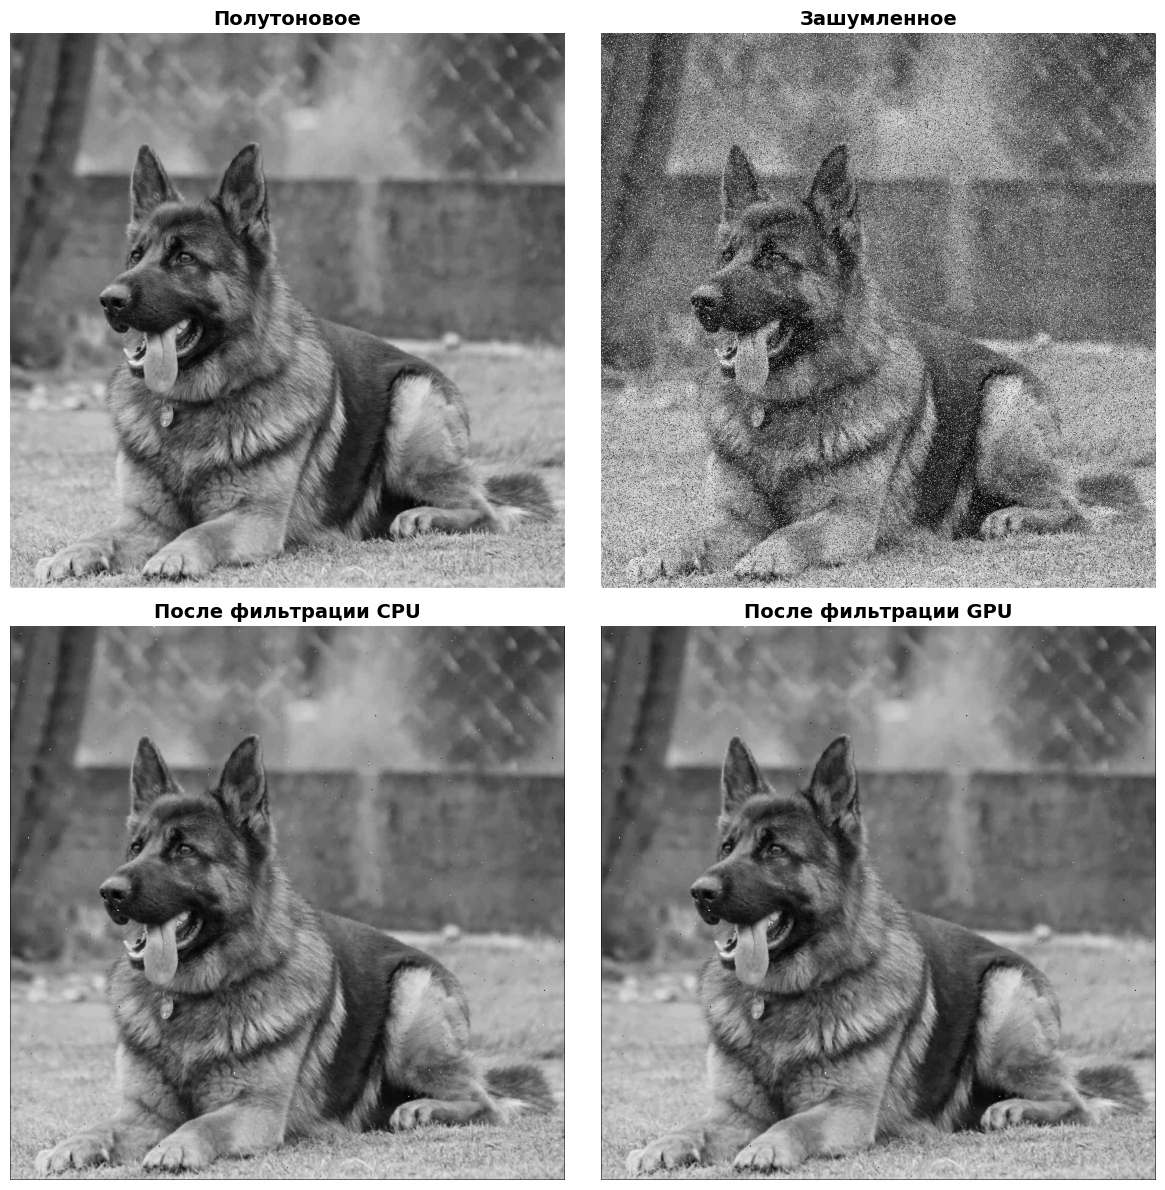

In [21]:
if __name__ == "__main__":
    main()